In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [31]:
def resize_image(img, new_width=800):
    height, width = img.shape[:2]
    aspect_ratio = height / width
    new_height = int(new_width * aspect_ratio)

    resized = cv2.resize(img, (new_width, new_height), interpolation=cv2.INTER_AREA)
    resized_image = resized.copy()
    return resized_image

In [32]:
# param1 = 170
# param2 = 60

param1 = 180
param2 = 40

def preprocess_image(img):
    resized = resize_image(img)

    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    # gray = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)

    clahe = cv2.createCLAHE(clipLimit=0.8, tileGridSize=(10, 10))
    gray_clahe = clahe.apply(gray)

    # blur = cv2.GaussianBlur(gray_clahe, (11,11), 3)
    blur = cv2.medianBlur(gray_clahe, 7)

    return blur


In [33]:
def get_circles(img):
    circles = cv2.HoughCircles(
        preprocess_image(img),
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=40,
        param1 = param1,
        param2 = param2,
        minRadius=40,
        maxRadius=150
    )

    return circles

In [34]:
# def get_reference_circle(circles, img):

#     resized = resize_image(img)

#     hsv = cv2.cvtColor(resized, cv2.COLOR_BGR2HSV)

#     lower_blue = np.array([95, 5, 100])
#     upper_blue = np.array([120, 40, 240])

#     blue_mask = cv2.inRange(hsv, lower_blue, upper_blue)

#     circles_arr = circles[0, :]

#     valid_circles = []

#     for circle in circles_arr:

#         x, y, r = circle

#         xi, yi, ri = int(x), int(y), int(r)

#         mask = np.zeros(hsv.shape[:2], dtype=np.uint8)

#         cv2.circle(mask, (xi, yi), ri, 255, -1)

#         blue_pixels = cv2.countNonZero(
#             cv2.bitwise_and(blue_mask, blue_mask, mask=mask)
#         )

#         area = np.pi * (r ** 2)
#         blue_density = blue_pixels / area
#         if blue_density > 0.5:
#             valid_circles.append(circle)

#     if valid_circles:
#         return max(valid_circles, key=lambda c: c[2])

#     return None

In [35]:
def get_reference_circle(circles, img,
                         blue_threshold=85,
                         saturation_threshold=16):

    resized = resize_image(img)

    hsv = cv2.cvtColor(resized, cv2.COLOR_BGR2HSV)

    circles_arr = circles[0, :]

    sorted_circles = sorted(circles_arr, key=lambda c: c[2], reverse=True)

    for circle in sorted_circles:

        x, y, r = circle

        xi, yi, ri = int(x), int(y), int(r)

        mask = np.zeros(hsv.shape[:2], dtype=np.uint8)

        cv2.circle(mask, (xi, yi), ri, 255, -1)

        mean_h, mean_s, mean_v, _ = cv2.mean(hsv, mask=mask)

        is_blue = (
            blue_threshold <= mean_h <= 120 and
            mean_s >= saturation_threshold
        )

        if is_blue:
            return circle

    return None

In [36]:
def display_radii(circles):
    if circles is not None:
        circles = circles[0, :]
        for i, circle in enumerate(circles):
            x, y, r = circle
            print(f"Circle {i+1}: radius = {r:.2f} px")

        radii = [c[2] for c in circles]
        plt.figure(figsize=(5, 3))
        plt.hist(radii, bins=20, color='blue', edgecolor='black')
        plt.title('Distribution of Detected Coin Radii')
        plt.xlabel('Radius (pixels)')
        plt.ylabel('Frequency')
        plt.show()

In [37]:
def draw_text_outline(img, text, pos, font, scale, color, thickness):
    x, y = pos

    cv2.putText(img, text, (x-1, y-1), font, scale, (0,0,0), thickness+2, cv2.LINE_AA)
    cv2.putText(img, text, (x+1, y-1), font, scale, (0,0,0), thickness+2, cv2.LINE_AA)
    cv2.putText(img, text, (x-1, y+1), font, scale, (0,0,0), thickness+2, cv2.LINE_AA)
    cv2.putText(img, text, (x+1, y+1), font, scale, (0,0,0), thickness+2, cv2.LINE_AA)

    cv2.putText(img, text, (x, y), font, scale, color, thickness, cv2.LINE_AA)

In [38]:
def check_coin_validity(circle, img, fill_ratio_threshold=0.90):

    resized = resize_image(img)

    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    x, y, r = circle

    xi, yi, ri = int(x), int(y), int(r)

    h, w = gray.shape

    foreground = gray > 20

    circle_mask = np.zeros((h, w), dtype=np.uint8)

    cv2.circle(circle_mask, (xi, yi), ri, 255, -1)

    foreground_inside = np.logical_and(
        foreground,
        circle_mask > 0
    )

    foreground_pixels = np.count_nonzero(foreground_inside)

    area = np.pi * (r ** 2)
    fill_ratio = foreground_pixels / area
    is_valid = fill_ratio > fill_ratio_threshold

    return {
        "valid": is_valid,
        "fill_ratio": fill_ratio
    }

In [39]:
def display_circles(circles, img, centroids=None, labels=None, threshold=0.06):
    reference_circle = get_reference_circle(circles, img)
    reference_radius = reference_circle[2] if reference_circle is not None else 70

    circles = circles[0, :]
    resized_image = resize_image(img)

    centroids = np.array(centroids) if centroids is not None else None

    coin_counter = 0
    total_sum_value = 0

    for circle in circles:
        x, y, r = circle
        xi, yi, ri = int(x), int(y), int(r)

        if np.array_equal(circle, reference_circle):
            cv2.circle(resized_image, (xi, yi), ri, (255, 0, 255), 3)
            continue

        if centroids is not None and labels is not None:
            scaled_radius = r / reference_radius

            distances = np.abs(centroids - scaled_radius)
            nearest_idx = np.argmin(distances)

            if distances[nearest_idx] > threshold:
                continue

            validity = check_coin_validity(circle, img)
            if not validity["valid"]:
                continue

            coin_label = labels[nearest_idx]
            total_sum_value += int(coin_label)
            cv2.circle(resized_image, (xi, yi), ri, (0, 255, 0), 2)
            coin_counter += 1

            draw_text_outline(
                resized_image,
                str(coin_label),
                (xi - 30, yi + 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,
                (255, 200, 100),
                2
            )

        else:
            cv2.circle(resized_image, (xi, yi), ri, (0, 255, 0), 2)
            coin_counter += 1

    print(f"Total valid coins detected: {coin_counter}")
    print(f"Total sum value: {total_sum_value}")

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(preprocess_image(img), cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.show()

In [40]:
def print_circle_blue_scores(circles, img):

    resized = resize_image(img)

    hsv = cv2.cvtColor(resized, cv2.COLOR_BGR2HSV)

    circles_arr = circles[0, :]

    for i, circle in enumerate(circles_arr):

        x, y, r = circle

        xi, yi, ri = int(x), int(y), int(r)

        mask = np.zeros(hsv.shape[:2], dtype=np.uint8)

        cv2.circle(mask, (xi, yi), ri, 255, -1)

        mean_h, mean_s, _, _ = cv2.mean(hsv, mask=mask)


        print(
            f"Circle {i}: "
            f"center=({x:.1f}, {y:.1f}), "
            f"radius={r:.2f}, "
            f"avg_H={mean_h:.1f}, "
            f"avg_S={mean_s:.1f}, "
        )

In [41]:
centroids = [0.72410345, 0.7875909, 0.8518564]

Processing image 1...
Total valid coins detected: 7
Total sum value: 1800


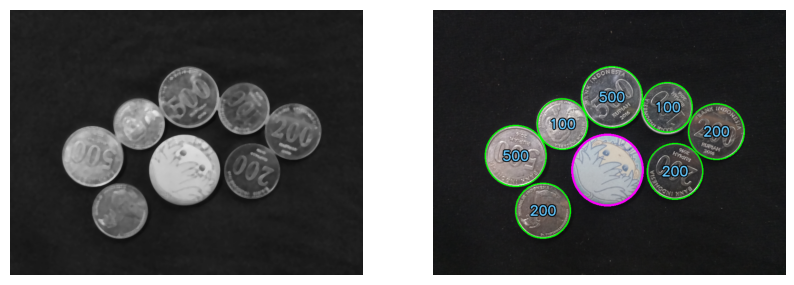

Processing image 2...
Total valid coins detected: 9
Total sum value: 3000


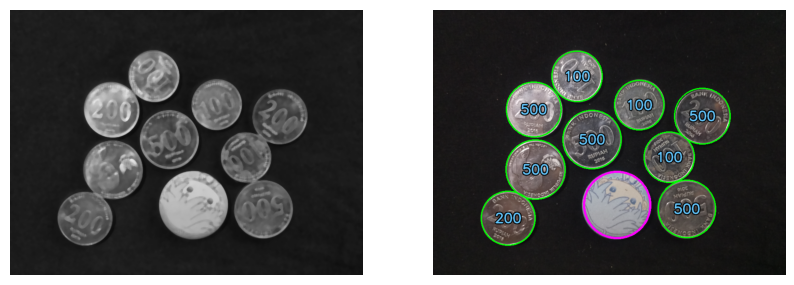

Processing image 3...
Total valid coins detected: 5
Total sum value: 1400


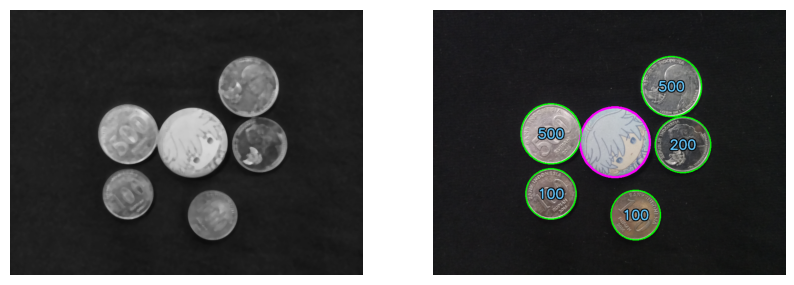

Processing image 4...
Total valid coins detected: 8
Total sum value: 2300


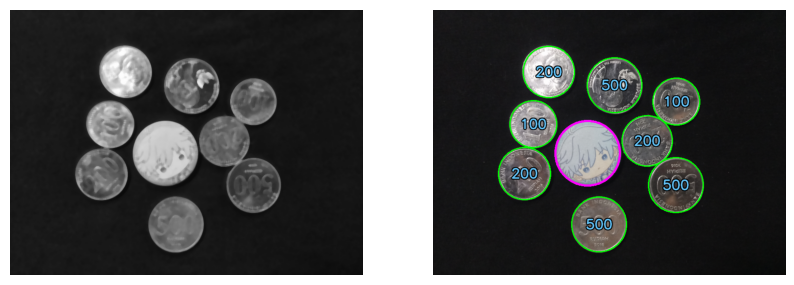

Processing image 5...
Total valid coins detected: 7
Total sum value: 2500


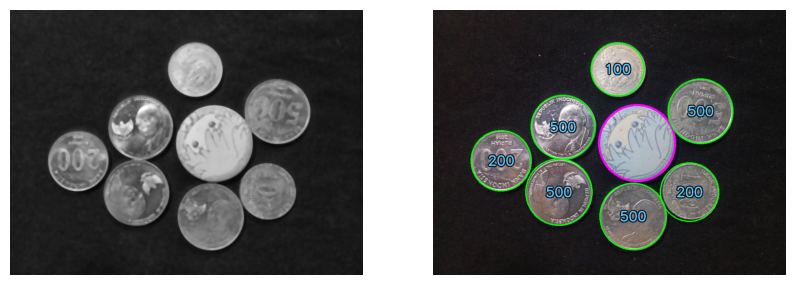

Processing image 6...
Total valid coins detected: 10
Total sum value: 3600


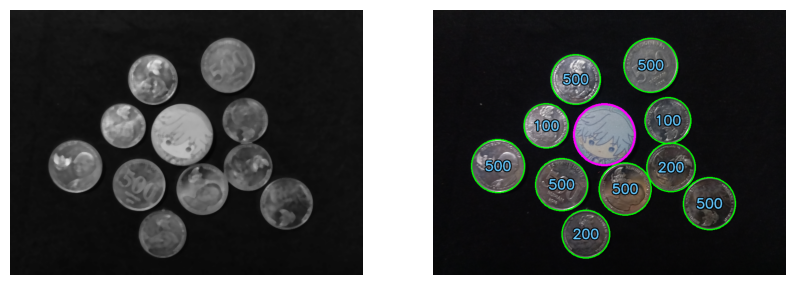

Processing image 7...
Total valid coins detected: 8
Total sum value: 2200


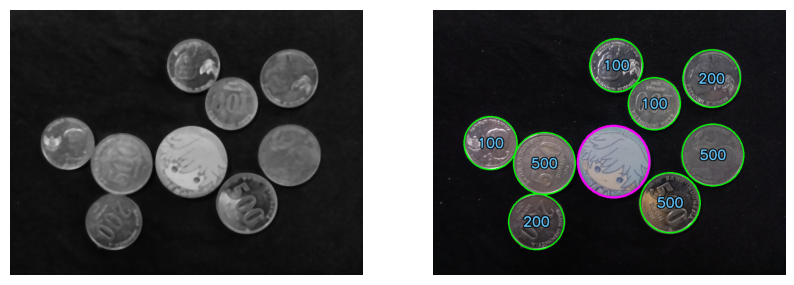

Processing image 8...
Total valid coins detected: 10
Total sum value: 2200


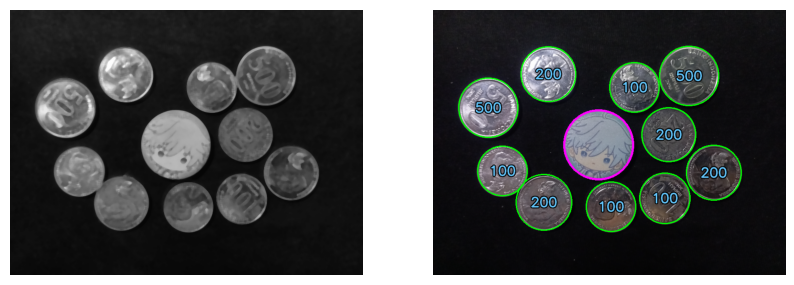

Processing image 9...
Total valid coins detected: 7
Total sum value: 2200


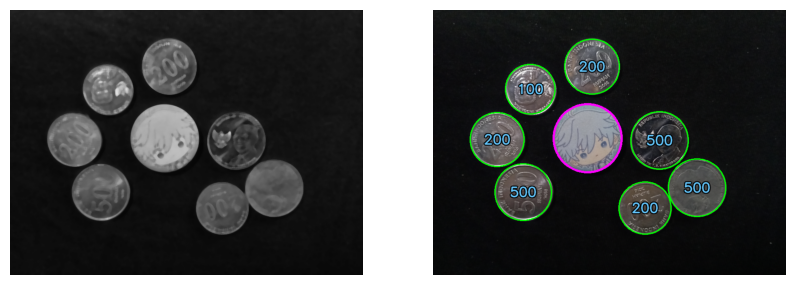

Processing image 10...
Total valid coins detected: 9
Total sum value: 1700


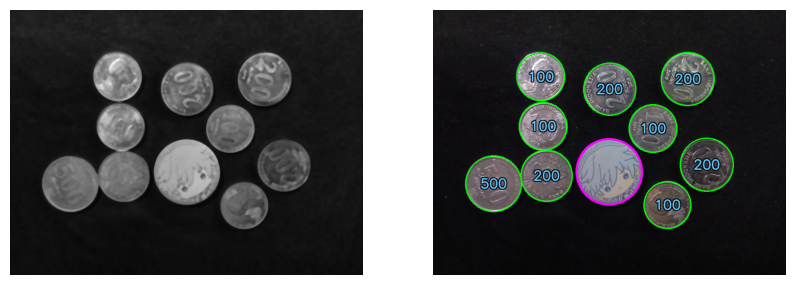

In [42]:
labels = ['100', '200', '500']
test_counter = 0

test_folder = "Test"
for filename in os.listdir(test_folder):
    if filename.endswith((".jpg", ".png")):
        img_path = os.path.join(test_folder, filename)
        img = cv2.imread(img_path)
        test_counter += 1
        print(f"Processing image {test_counter}...")

        circles = get_circles(img)

        if circles is not None:
            # display_radii(circles)
            # print_circle_blue_scores(circles, img)
            display_circles(circles, img, centroids, labels)

Total valid coins detected: 18
Total sum value: 4800


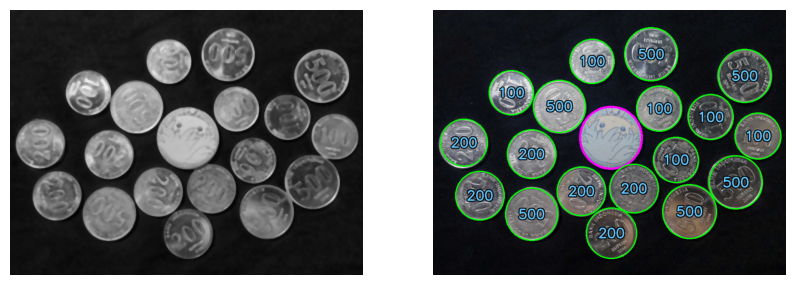

In [44]:
img = cv2.imread("IMG_20260525_2007115.jpg")
circles = get_circles(img)
if circles is not None:
    display_circles(circles, img, centroids, labels)